# PROG8431 - Data Analysis
## Group 5 Assignment 1

###Team Members
- Juan Antonio Sainz Galvez 9072844
- Asangika Hettiarachchi

** Dataset:** Ontario Residential Property Data
#https://www.kaggle.com/datasets/mnabaee/ontarioproperties
#Change the name of the dataset to "properties.csv"

## Challenge 1 - Research area and plan to establish a question.
### Field of Inquiry
Ontario Residential Real Estate Market
### Research Question
Abstract:What are some of the patterns we can observe in residential property prices between different regions in Ontario through descriptive statistics and geographic analysis?
### Use Case
This paper notes residential property prices throughout areas of Ontario. The aim is to discover price mismatches or geographic patterns that are valuable for buyers, sellers and real estate professionals observing the housing market.
### Question to consider from slide 20
**Will it be one-time or ongoing?**
Yes will be ongoing. 

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

print("Ready Professor")

Ready Professor


In [4]:
#Load dataset
data_path = "../data/properties.csv"
df = pd.read_csv(data_path)

df.head()

,Unnamed: 0,Address,AreaName,Price ($),lat,lng
0,0,"86 Waterford Dr Toronto, ON",Richview,999888,43.679882,-79.544266
1,1,"#80 - 100 BEDDOE DR Hamilton, ON",Chedoke Park B,399900,43.250000,-79.904396
2,2,"213 Bowman Street Hamilton, ON",Ainslie Wood East,479000,43.251690,-79.919357
3,3,"102 NEIL Avenue Hamilton, ON",Greenford,285900,43.227161,-79.767403
4,6,"#1409 - 230 King St Toronto, ON",Downtown,362000,43.651478,-79.368118


In [5]:
# Understand the structure of the dataset
print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)


Dataset shape: (25351, 6)

Column names:
['Unnamed: 0', 'Address', 'AreaName', 'Price ($)', 'lat', 'lng']

Data types:
Unnamed: 0      int64
Address           str
AreaName          str
Price ($)       int64
lat           float64
lng           float64
dtype: object


In [6]:
# Check data quality and missing values
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())


Missing values:
Unnamed: 0      0
Address         0
AreaName      483
Price ($)       0
lat             0
lng             0
dtype: int64

Duplicate rows:
0


### Findings
The dataset contains 25,351 records, no duplicate found.
The 'AreaName' column contains 483 missing values.

## Understanding the collected data
Dataset with 25,351 residential property records from Ontario, with price, address, lat and lng.

## Encapsulating code in classes and methods

In [7]:
class PropertyData:

    def __init__(self,data):
        self.data = data

    def show_data(self):
        return self.data.head()

    def dataset_shape(self):
        return self.data.shape

property_data = PropertyData(df)

print("Dataset shape:", property_data.dataset_shape())
property_data.show_data()

Dataset shape: (25351, 6)


,Unnamed: 0,Address,AreaName,Price ($),lat,lng
0,0,"86 Waterford Dr Toronto, ON",Richview,999888,43.679882,-79.544266
1,1,"#80 - 100 BEDDOE DR Hamilton, ON",Chedoke Park B,399900,43.250000,-79.904396
2,2,"213 Bowman Street Hamilton, ON",Ainslie Wood East,479000,43.251690,-79.919357
3,3,"102 NEIL Avenue Hamilton, ON",Greenford,285900,43.227161,-79.767403
4,6,"#1409 - 230 King St Toronto, ON",Downtown,362000,43.651478,-79.368118


## 50 word use case
Here we will analyze residential property data from Ontario to understand how prices vary across different areas. We use property prices, and location geographic coordinates, the analysis explores market patterns descriptive statistics and visualizations. The results can help buyers, sellers, and real estate professionals better understanding regional housing price differences.

## Mean, Median and Mode

In [8]:
mean_price = df["Price ($)"].mean()
median_price = df["Price ($)"].median()
mode_price = df["Price ($)"].mode()[0]

print(f"Mean Price: ${mean_price:.2f}")
print(f"Median Price: ${median_price:.2f}")
print(f"Mode Price: ${mode_price:.2f}")



Mean Price: $564543.77
Median Price: $371900.00
Mode Price: $299900.00


## Variance, Standard Deviation, and Quartiles

In [9]:
variance_price = df["Price ($)"].var()
std_price = df["Price ($)"].std()

quartiles = df["Price ($)"].quantile([0.25, 0.5, 0.75, 1.00])

print(f"Variance of Price: ${variance_price:.2f}")
print(f"Standard Deviation: ${std_price:.2f}")

print("Quartiles:")
print(quartiles)

Variance of Price: $718419262884.10
Standard Deviation: $847596.17
Quartiles:
0.25      219900.0
0.50      371900.0
0.75      619900.0
1.00    32500000.0
Name: Price ($), dtype: float64


### Scatter Plot

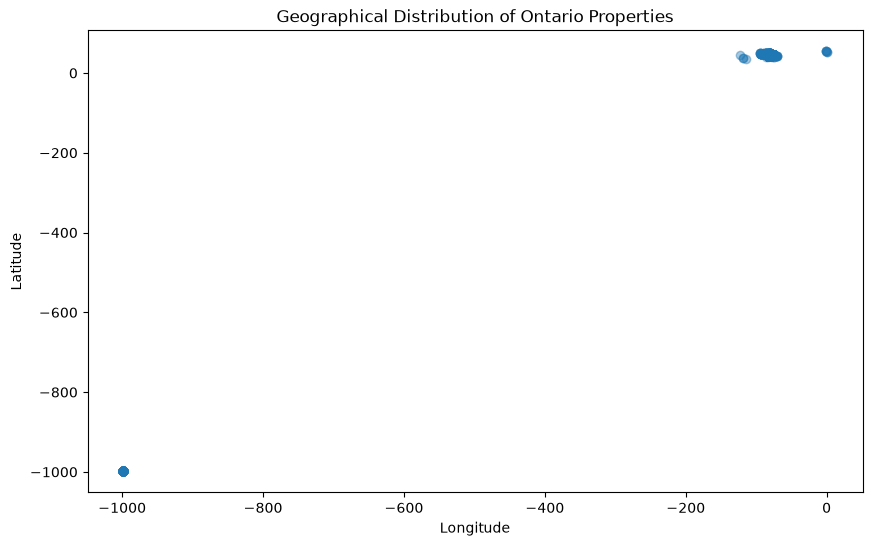

In [10]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df["lng"],
    df["lat"],
    alpha=0.4       
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographical Distribution of Ontario Properties")

plt.show()

### Histogram

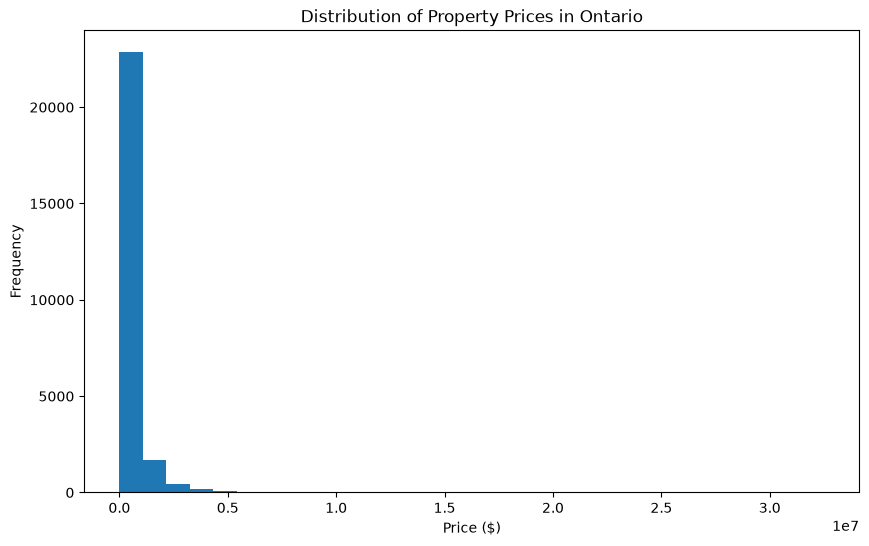

In [11]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["Price ($)"], bins=30)
plt.xlabel("Price ($)")
plt.ylabel("Frequency")
plt.title("Distribution of Property Prices in Ontario")
plt.show()



### Box and Whisker Plot

C:\Users\anton\AppData\Local\Temp\ipykernel_8072\2307677261.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df["Price ($)"], vert=False)


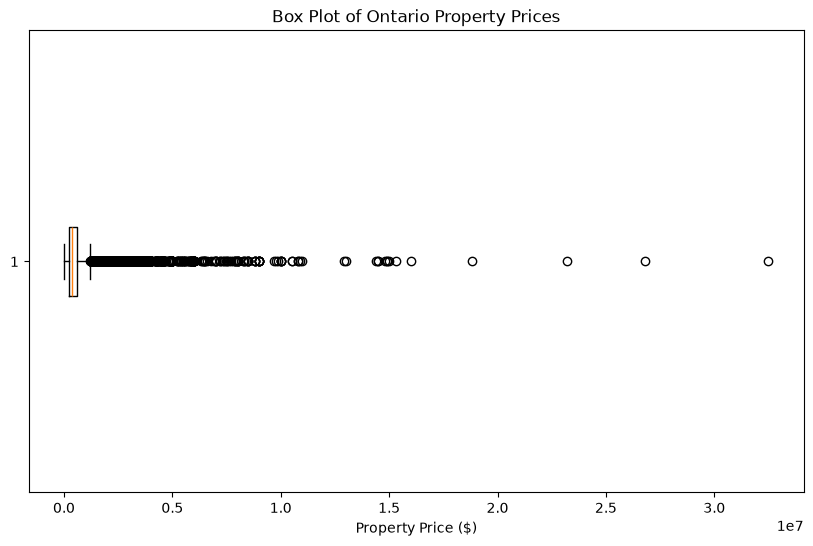

In [12]:
plt.figure(figsize=(10, 6))

plt.boxplot(df["Price ($)"], vert=False)

plt.xlabel("Property Price ($)")
plt.title("Box Plot of Ontario Property Prices")

plt.show()

In [ ]:
### Venn Diagram


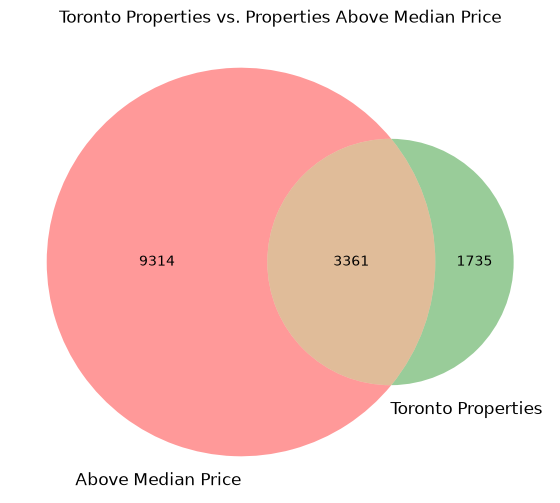

In [13]:
above_median = set(df[df["Price ($)"] > median_price].index)

toronto = set(
    df[df["Address"].str.contains("Toronto", case=False, na=False)].index
)

plt.figure(figsize=(8, 6))

venn2(
    [above_median, toronto],
    set_labels=("Above Median Price", "Toronto Properties")
)

plt.title("Toronto Properties vs. Properties Above Median Price")
plt.show()

### Summary

In [14]:
price_summary = df["Price ($)"].describe()

price_summary

count    2.535100e+04
mean     5.645438e+05
std      8.475962e+05
min      0.000000e+00
25%      2.199000e+05
50%      3.719000e+05
75%      6.199000e+05
max      3.250000e+07
Name: Price ($), dtype: float64